In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [19]:
df = pd.read_csv('goog.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [20]:
df['Date'] = pd.to_datetime(df['Date'])

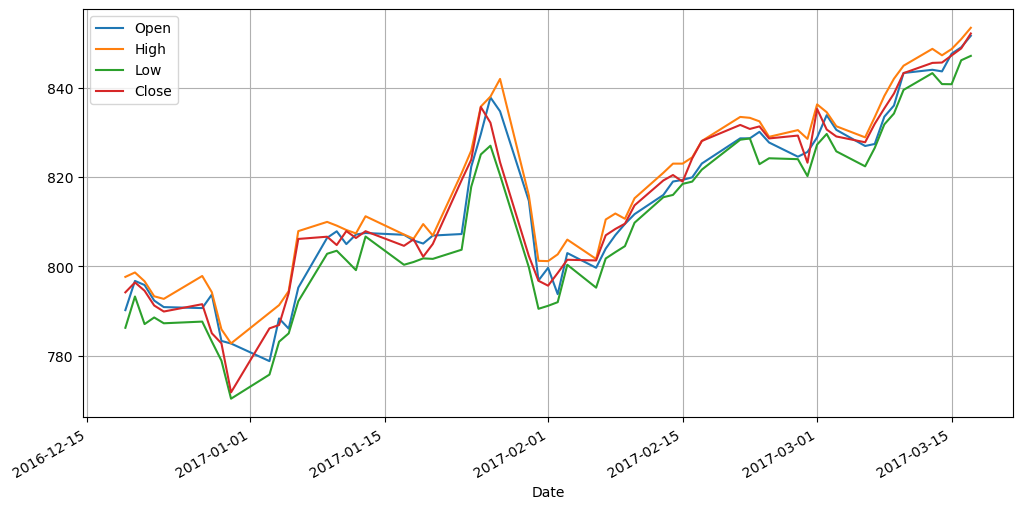

In [21]:
fig = df.plot(
    x = 'Date',
    y = ['Open', 'High', 'Low', 'Close'],
    figsize = (12, 6),
)
plt.grid(True)
plt.show()

In [22]:
data = df.drop('Date', axis=1)

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [24]:
def create_sequences(data, target_col_index, seq_len=10):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i - seq_len : i])
        y.append(data[i, target_col_index])
    return np.array(x), np.array(y)

x, y = create_sequences(scaled_data, target_col_index=3)

In [25]:
x

array([[[0.15673043, 0.2107044 , 0.20678024, 0.27870496, 0.2312416 ],
        [0.24656614, 0.22472382, 0.29804489, 0.30635093, 0.11579351],
        [0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        ...,
        [0.06208818, 0.04460442, 0.11095187, 0.13661236, 0.04559585],
        [0.05412092, 0.        , 0.        , 0.        , 0.43630781],
        [0.        , 0.09699768, 0.07027398, 0.17833138, 0.39136442]],

       [[0.24656614, 0.22472382, 0.29804489, 0.30635093, 0.11579351],
        [0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        [0.18612623, 0.1492492 , 0.23689754, 0.24209223, 0.13268087],
        ...,
        [0.05412092, 0.        , 0.        , 0.        , 0.43630781],
        [0.        , 0.09699768, 0.07027398, 0.17833138, 0.39136442],
        [0.13118116, 0.1212121 , 0.16623205, 0.18779601, 0.16964114]],

       [[0.23392901, 0.19677141, 0.21760105, 0.28318798, 0.22464018],
        [0.18612623, 0.1492492 , 0.23689754, 0.24209223, 0.1

In [26]:
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [27]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape = (x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 10, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    x_train,
    y_train,
    epochs = 50,
    batch_size = 32,
    validation_data = (x_test, y_test)
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 529ms/step - loss: 0.2668 - val_loss: 0.2766
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1166 - val_loss: 0.0439
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0371 - val_loss: 0.0231
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0442 - val_loss: 0.0604
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0609 - val_loss: 0.0260
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0439 - val_loss: 0.0050
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0273 - val_loss: 0.0203
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0251 - val_loss: 0.0480
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0328 - val_loss: 0.0649
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0391 - val_loss: 0.0638
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0328 - val_loss: 0.0520
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0318 - val_loss: 0

In [29]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


In [30]:
close_scaler = MinMaxScaler()

close_scaler.min_, close_scaler.scale_ = scaler.min_[3:4], scaler.scale_[3:4]

In [31]:
predicted_values = close_scaler.inverse_transform(y_pred)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1, 1))

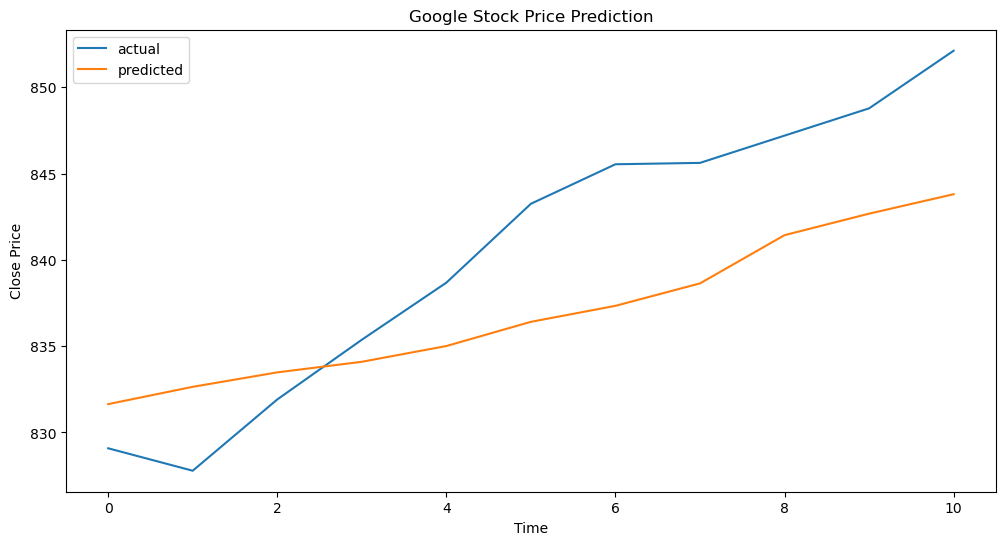

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='actual')
plt.plot(predicted_values, label='predicted')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [34]:

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  5.643629599983488
MAE:  5.105368871803969
R2 Score:  0.5018259628984665
